# **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Install missingno**

In [2]:
!pip install missingno

# **Import missingno**

In [4]:
import missingno as msno

# **Read the CSV File**

In [10]:
df = pd.read_csv("/content/sample_data/ops_sensor_log_dirty (2).csv")

# **View the Data**

In [11]:
df.head()

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
0,2026-07-01 18:28:00,Zone_South,Night,159.443407,83.599922,693.413088
1,2026-06-26 10:10:00,Zone_Central,NaN,271.325543,54.108382,933.590883
2,2026-06-29 22:10:00,Zone_Central,Morning,207.832279,72.549214,863.540549
3,2026-06-30 07:22:00,Zone_East,Night,203.110883,73.029484,1189.537650
4,2026-07-01 02:28:00,Zone_North,Morning,239.773496,73.752762,983.672559


# **Check the Dataset Size**

In [13]:
df.shape

(5015, 6)

# **View Dataset Information**

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      5015 non-null   object 
 1   Zone           4984 non-null   object 
 2   Shift          4962 non-null   object 
 3   Pressure_PSI   4975 non-null   float64
 4   Temperature_C  4975 non-null   float64
 5   Flow_Rate_LPM  4966 non-null   float64
dtypes: float64(3), object(3)
memory usage: 235.2+ KB


# **View Summary Statistics**

In [15]:
df.describe()

,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,4975.000000,4975.000000,4966.000000
mean,255.254281,68.982323,999.275681
std,845.810206,78.829078,231.769525
min,-50.000000,-273.150000,600.007437
25%,160.753008,55.023155,797.417014
50%,200.294439,64.808608,996.286415
75%,240.099173,74.527006,1201.361276
max,15000.000000,1500.000000,1399.755865


# **Count Missing Values**

In [16]:
df.isnull().sum()

,0
timestamp,0
Zone,31
Shift,53
Pressure_PSI,40
Temperature_C,40
Flow_Rate_LPM,49


# **Visualize Missing Values**

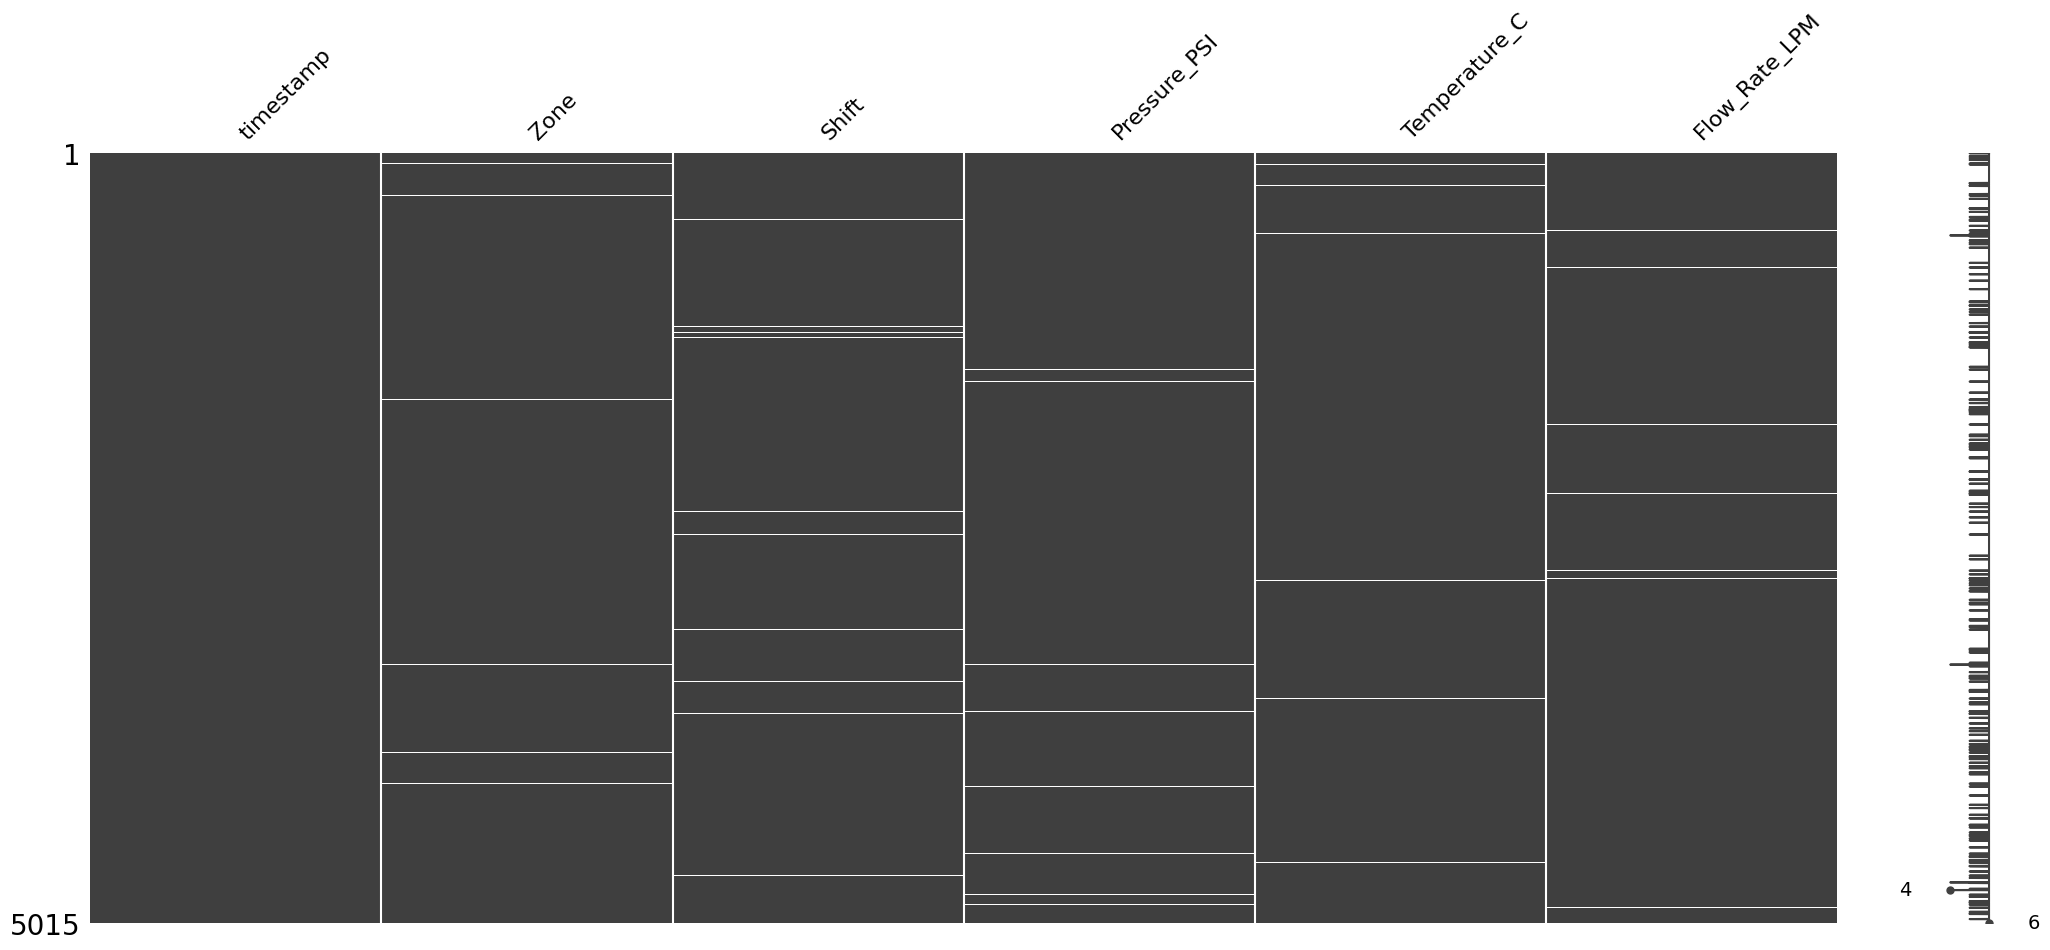

In [17]:
msno.matrix(df)
plt.show()

# **Data Health Report**

The dataset was successfully loaded and examined.

The following quality issues were identified:

1. Missing values exist in the Pressure column.
2. Timestamp is stored as text instead of datetime.
3. Some pressure readings appear to be outside the expected operating range.
4. Zone names contain inconsistent formatting.

# **Task 2: Cleaning Pipeline**

In [55]:
def clean_ops_data(df):
    # Create a copy to avoid modifying the original DataFrame outside the function scope
    cleaned_df = df.copy()

    # Step 2.2 Convert Timestamp
    cleaned_df["timestamp"] = pd.to_datetime(cleaned_df["timestamp"])

    # Step 2.3 Handle Missing Values (Pressure_PSI)
    cleaned_df["Pressure_PSI"] = cleaned_df["Pressure_PSI"].interpolate()

    # Step 2.4 Remove Duplicates
    cleaned_df = cleaned_df.drop_duplicates()

    # Step 2.5 Standardize Categories (Zone)
    cleaned_df["Zone"] = cleaned_df["Zone"].str.upper().str.strip()

    # Step 2.6 Remove Impossible Sensor Values (Pressure_PSI)
    cleaned_df = cleaned_df[(cleaned_df["Pressure_PSI"] >= 0) & (cleaned_df["Pressure_PSI"] <= 300)]

    return cleaned_df

# **Step 2.2 Convert Timestamp**

In [29]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      5015 non-null   datetime64[ns]
 1   Zone           4984 non-null   object        
 2   Shift          4962 non-null   object        
 3   Pressure_PSI   4975 non-null   float64       
 4   Temperature_C  4975 non-null   float64       
 5   Flow_Rate_LPM  4966 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 235.2+ KB


# **Step 2.3 Handle Missing Values**

In [37]:
df["Pressure_PSI"] = df["Pressure_PSI"].interpolate()

In [36]:
df["Pressure_PSI"].isnull().sum()

np.int64(0)

## Handling Missing Values

Missing pressure values were filled using interpolation.

Interpolation estimates missing sensor readings based on neighbouring values, making it suitable for continuously changing measurements like pressure.

# **Step 2.4 Remove Duplicates**

In [38]:
df = df.drop_duplicates()

In [39]:
df.shape

(5000, 6)

## Removing Duplicates

Duplicate records were removed because they represent repeated measurements and would distort summary statistics and averages.

# **Step 2.5 Standardize Categories**

In [40]:
df["Zone"] = df["Zone"].str.upper().str.strip()

/tmp/ipykernel_1189/1882499142.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Zone"] = df["Zone"].str.upper().str.strip()


In [41]:
df["Zone"].unique()

array(['ZONE_SOUTH', 'ZONE_CENTRAL', 'ZONE_EAST', 'ZONE_NORTH',
       'ZONE_WEST', nan, 'Z_SOUTH', 'Z_NORTH', 'ZONE NORTH', 'SOUTH ZONE',
       'NORTH ZONE', 'ZONE-NORTH', 'ZONE SOUTH'], dtype=object)

## Standardizing Categories

Zone names were converted to uppercase and extra spaces removed to ensure identical locations are grouped together correctly.

# **Step 2.6 Remove Impossible Sensor Values**

In [46]:
df = df[(df["Pressure_PSI"] >= 0) & (df["Pressure_PSI"] <= 300)]

In [47]:
df.describe()

,timestamp,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,4963,4963.000000,4923.000000,4915.000000
mean,2026-06-28 10:19:28.712472320,199.615660,69.015673,999.220522
min,2026-01-07 09:10:00,0.000000,-273.150000,600.007437
25%,2026-06-26 17:25:00,160.995524,55.018155,797.195017
50%,2026-06-28 11:04:00,200.231587,64.797702,996.295353
75%,2026-06-30 04:49:00,239.638705,74.523099,1201.211583
max,2026-07-01 22:38:00,279.958604,1500.000000,1399.755865
std,NaN,47.131134,79.235791,231.788929


## Removing Invalid Sensor Readings

Pressure values outside the expected operating range were removed because they are physically impossible and likely represent sensor or recording errors.

**Final Step of Task 2**

Run the cleaning function.

In [57]:
clean_df = clean_ops_data(df)

In [58]:
clean_df.head()

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
0,2026-07-01 18:28:00,ZONE_SOUTH,Night,159.443407,83.599922,693.413088
1,2026-06-26 10:10:00,ZONE_CENTRAL,NaN,271.325543,54.108382,933.590883
2,2026-06-29 22:10:00,ZONE_CENTRAL,Morning,207.832279,72.549214,863.540549
3,2026-06-30 07:22:00,ZONE_EAST,Night,203.110883,73.029484,1189.537650
4,2026-07-01 02:28:00,ZONE_NORTH,Morning,239.773496,73.752762,983.672559


**TASK 3: TIME-SERIES ANALYSIS**

**Step 3.1 Set Timestamp as Index**

In [87]:
clean_df.head()

,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
timestamp,,,,,
2026-07-01 18:28:00,ZONE_SOUTH,Night,159.443407,83.599922,693.413088
2026-06-26 10:10:00,ZONE_CENTRAL,NaN,271.325543,54.108382,933.590883
2026-06-29 22:10:00,ZONE_CENTRAL,Morning,207.832279,72.549214,863.540549
2026-06-30 07:22:00,ZONE_EAST,Night,203.110883,73.029484,1189.537650
2026-07-01 02:28:00,ZONE_NORTH,Morning,239.773496,73.752762,983.672559


**Step 3.2 Resample Hourly**

In [91]:
hourly = clean_df.resample("H").mean(numeric_only=True)

/tmp/ipykernel_1189/1255305919.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = clean_df.resample("H").mean(numeric_only=True)


# **Step 3.3 Rolling Average**

In [96]:
hourly["Rolling24"] = hourly["Pressure_PSI"].rolling(24).mean()

In [97]:
hourly.head(30)

,Pressure_PSI,Temperature_C,Flow_Rate_LPM,Rolling24
timestamp,,,,
2026-01-07 09:00:00,139.019377,75.264388,1022.66937,NaN
2026-01-07 10:00:00,NaN,NaN,NaN,NaN
2026-01-07 11:00:00,NaN,NaN,NaN,NaN
2026-01-07 12:00:00,NaN,NaN,NaN,NaN
2026-01-07 13:00:00,NaN,NaN,NaN,NaN
2026-01-07 14:00:00,NaN,NaN,NaN,NaN
2026-01-07 15:00:00,NaN,NaN,NaN,NaN
2026-01-07 16:00:00,NaN,NaN,NaN,NaN
2026-01-07 17:00:00,NaN,NaN,NaN,NaN


# **TASK 4: AGGREGATION**

In [102]:
summary = clean_df.groupby(
    ["Shift","Zone"]
)["Pressure_PSI"].agg(["mean","max","min"])

# **TASK 5: VISUALIZATION**

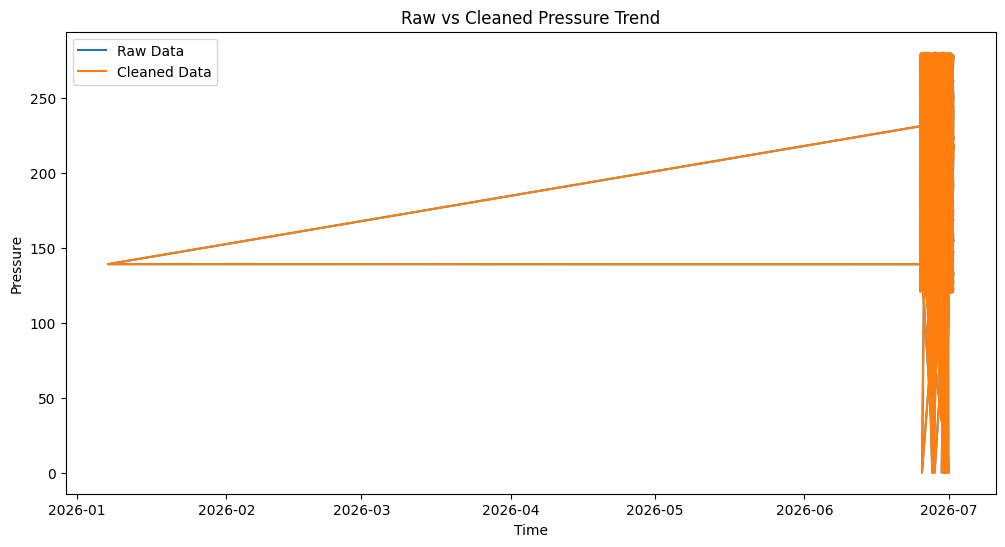

In [105]:
plt.figure(figsize=(12,6))

plt.plot(df["timestamp"], df["Pressure_PSI"], label="Raw Data")
plt.plot(clean_df.index, clean_df["Pressure_PSI"], label="Cleaned Data")

plt.xlabel("Time")
plt.ylabel("Pressure")
plt.title("Raw vs Cleaned Pressure Trend")
plt.legend()

plt.show()

# Final Summary

## Project Overview

This notebook analyzed and cleaned a week's operational sensor data from a fictional processing plant.

The dataset was first profiled to identify data quality issues, including missing values, duplicate records, inconsistent categorical values, and invalid sensor readings.

A reusable cleaning function (`clean_ops_data`) was developed to convert timestamps into datetime format, handle missing values using interpolation, remove duplicate records, standardize zone names, and filter out physically impossible pressure readings.

After cleaning, the data was analyzed using time-series techniques by resampling the readings to hourly intervals and calculating a 24-hour rolling average. A summary table was also generated to compare the mean, maximum, and minimum pressure values across different shifts and plant zones.

Finally, a visualization comparing the raw and cleaned data showed that the cleaning process removed invalid spikes and produced a clearer representation of the operational trend, making the data more reliable for analysis and decision-making.